In [7]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
import warnings 

warnings.filterwarnings("ignore")


In [2]:
pip install matplotlib 

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 6.6 MB/s eta 0:00:02
   ------------------------------ --------- 6.3/8.1 MB 18.3 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 13.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 10.5 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 26.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------- ----------------- 3.9/7.0 MB 39.0 MB/s eta 0:00:01
   ---------------------------- ----------- 5.0/7.0 MB 12.6 MB/s eta 0:00:01
   ------------------------------------- -- 6.6/7.0 MB 10.3 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 9.6 MB/s  0:

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [6]:
pip install plotly seaborn 

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.9 MB 9.1 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.9 MB 17.5 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 14.6 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 13.7 MB/s  0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [10]:
df = pd.read_csv(r"EasyVisa.csv")

In [11]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [12]:
df.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='str')

In [13]:
df.shape

(25480, 12)

In [14]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  str    
 1   continent              25480 non-null  str    
 2   education_of_employee  25480 non-null  str    
 3   has_job_experience     25480 non-null  str    
 4   requires_job_training  25480 non-null  str    
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  str    
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  str    
 10  full_time_position     25480 non-null  str    
 11  case_status            25480 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 2.3 MB


In [32]:
df.dtypes

case_id                      str
continent                    str
education_of_employee        str
has_job_experience           str
requires_job_training        str
no_of_employees            int64
yr_of_estab                int64
region_of_employment         str
prevailing_wage          float64
unit_of_wage                 str
full_time_position           str
case_status                  str
dtype: object

In [35]:
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']
len(numerical_features) ,len(categorical_features)  


(3, 9)

In [41]:
# propotion if count data on categorical columns


for col in categorical_features:
    print(df[col].value_counts(normalize=True)*100)

case_id
EZYV01       0.003925
EZYV02       0.003925
EZYV03       0.003925
EZYV04       0.003925
EZYV05       0.003925
EZYV06       0.003925
EZYV07       0.003925
EZYV08       0.003925
EZYV09       0.003925
EZYV10       0.003925
EZYV11       0.003925
EZYV12       0.003925
EZYV13       0.003925
EZYV14       0.003925
EZYV15       0.003925
EZYV16       0.003925
EZYV17       0.003925
EZYV18       0.003925
EZYV19       0.003925
EZYV20       0.003925
EZYV21       0.003925
EZYV22       0.003925
EZYV23       0.003925
EZYV24       0.003925
EZYV25       0.003925
EZYV26       0.003925
EZYV27       0.003925
EZYV28       0.003925
EZYV29       0.003925
EZYV30       0.003925
EZYV31       0.003925
EZYV32       0.003925
EZYV33       0.003925
EZYV34       0.003925
EZYV35       0.003925
EZYV36       0.003925
EZYV37       0.003925
EZYV38       0.003925
EZYV39       0.003925
EZYV40       0.003925
EZYV41       0.003925
EZYV42       0.003925
EZYV43       0.003925
EZYV44       0.003925
EZYV45       0.003925
EZ


#### `case_id ` have unique values so not important 
#### `continent` highly baised towards Asia 

#### Univariate Analysis 
- the Analysis of single variable.
- Bivariate : of two variables , Multivariate : of two or more variables.

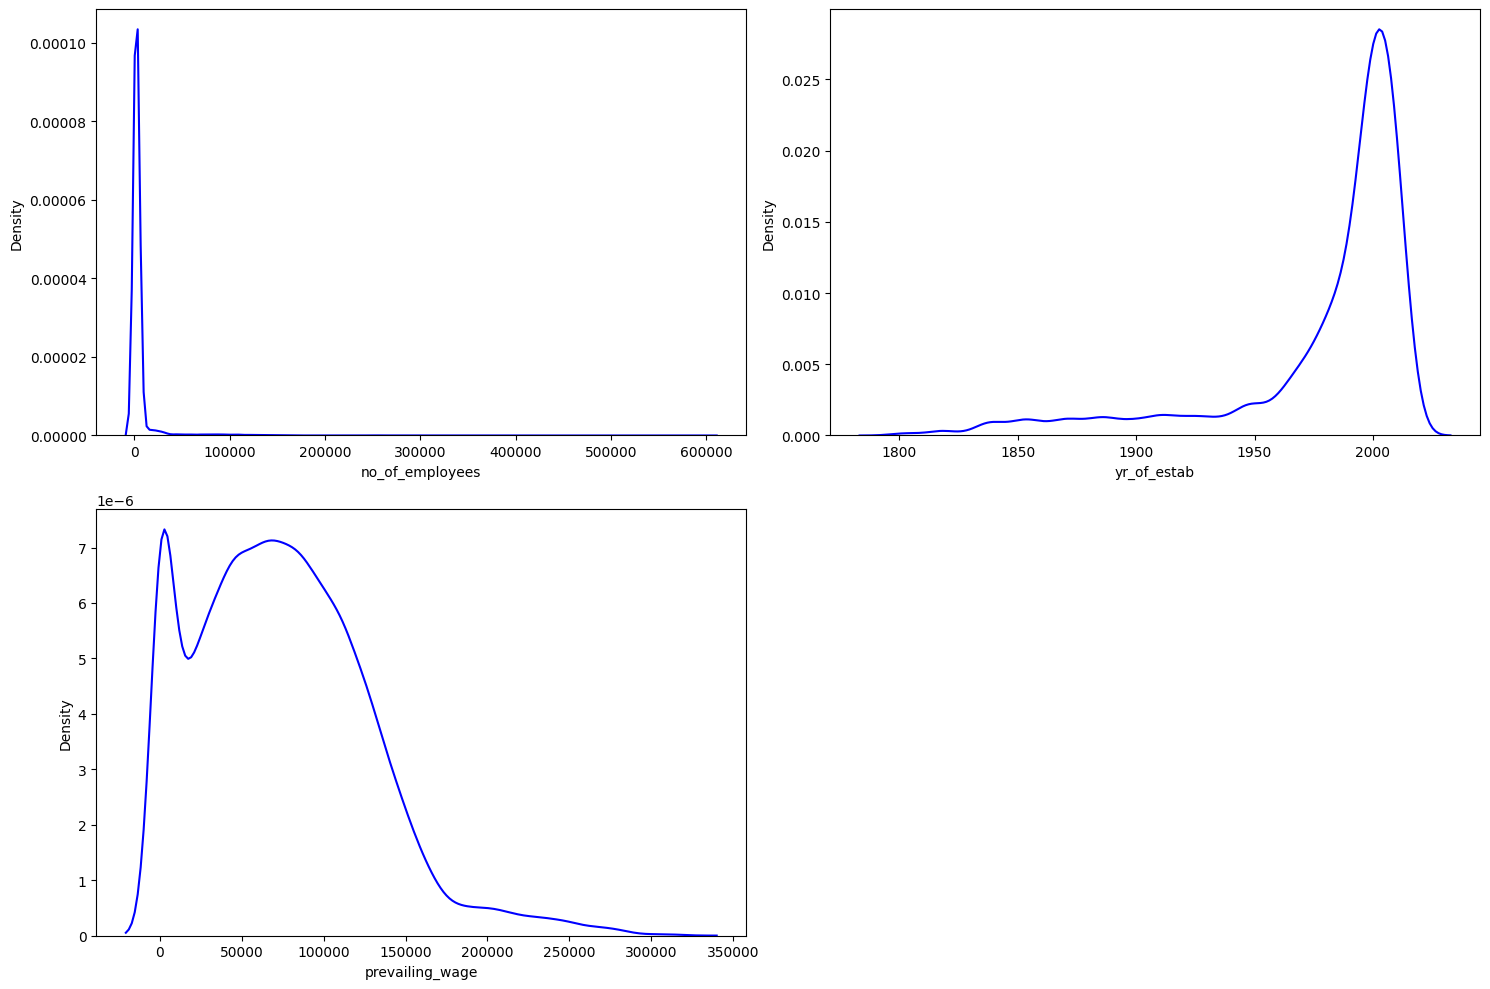

In [45]:
plt.figure(figsize=(15,10))

for i in range(0, len(numerical_features)):
    plt.subplot(2,2,i+1)
    sns.kdeplot(x=df[numerical_features[i]],color='blue')
    plt.xlabel(numerical_features[i])
    plt.tight_layout()



#
- `no_of_cols` : skewed 
- `privaling-wage` : right skewed


In [56]:
    categorical_features

['case_id',
 'continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [66]:
categorical_features.remove('case_id')


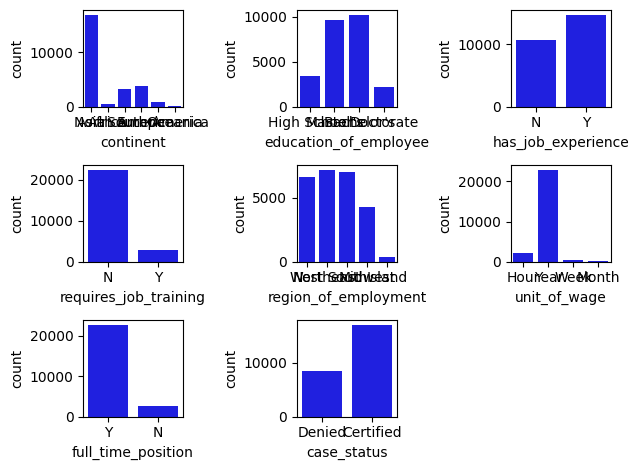

In [67]:
for i in range(0, len(categorical_features)):
    plt.subplot(3,3,i+1)
    sns.countplot(x=df[categorical_features[i]],color='blue')
    plt.xlabel(categorical_features[i])
    plt.tight_layout()


- `requires_job_training` ,`unit_of_wage` , `full_time_position` and `continent` has single category most demand 

# multivariate Analysis 
is the analysis of more than one variable.

In [71]:
discrete_features = [feature for feature in numerical_features if len(df[feature].unique())<=25 ]
continous_features = [feature for feature in numerical_features if len(df[feature].unique()) > 25 ]
print('we have {} discrete features'.format(len(discrete_features) ))
print('we have {} continous features'.format(len(continous_features) ))


we have 0 discrete features
we have 3 continous features


In [74]:
 df.isna().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64